In [49]:
import pandas as pd
from sklearn.linear_model import LinearRegression,Lasso,Ridge,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,classification_report,confusion_matrix,mean_absolute_error
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import PolynomialFeatures,StandardScaler,MinMaxScaler,LabelEncoder
import seaborn as sns
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB,GaussianNB
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
import datetime as dt

In [50]:
df=pd.read_csv('fastag_fraud_detection.csv')

In [51]:
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Transaction_ID         5000 non-null   int64 
 1   Timestamp              5000 non-null   object
 2   Vehicle_Type           5000 non-null   object
 3   FastagID               4451 non-null   object
 4   TollBoothID            5000 non-null   object
 5   Lane_Type              5000 non-null   object
 6   Vehicle_Dimensions     5000 non-null   object
 7   Transaction_Amount     5000 non-null   int64 
 8   Amount_paid            5000 non-null   int64 
 9   Geographical_Location  5000 non-null   object
 10  Vehicle_Speed          5000 non-null   int64 
 11  Vehicle_Plate_Number   5000 non-null   object
 12  Fraud_indicator        5000 non-null   object
dtypes: int64(4), object(9)
memory usage: 507.9+ KB


In [53]:
df.shape

(5000, 13)

In [54]:
df.isna().sum()

Transaction_ID             0
Timestamp                  0
Vehicle_Type               0
FastagID                 549
TollBoothID                0
Lane_Type                  0
Vehicle_Dimensions         0
Transaction_Amount         0
Amount_paid                0
Geographical_Location      0
Vehicle_Speed              0
Vehicle_Plate_Number       0
Fraud_indicator            0
dtype: int64

In [55]:
df[df['FastagID'].isna()].head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud
9,10,1/15/2023 7:30,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",72,KA22ST6789,Not Fraud
16,17,1/22/2023 16:45,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",62,KA20GH1345,Not Fraud
23,24,1/29/2023 3:05,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",77,KA77UV0123,Not Fraud
30,31,2/5/2023 13:20,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",57,KA92IJ5789,Not Fraud


In [56]:
df['Vehicle_Type'].value_counts()

Vehicle_Type
Bus           716
Car           714
Motorcycle    714
Truck         714
Van           714
Sedan         714
SUV           714
Name: count, dtype: int64

In [57]:
df['Vehicle_Type'].unique()

array(['Bus ', 'Car', 'Motorcycle', 'Truck', 'Van', 'Sedan', 'SUV'],
      dtype=object)

In [58]:
df['Vehicle_Type'] = df['Vehicle_Type'].str.strip()

In [59]:
df['Vehicle_Type'].unique()

array(['Bus', 'Car', 'Motorcycle', 'Truck', 'Van', 'Sedan', 'SUV'],
      dtype=object)

In [60]:
df[df['Vehicle_Type']=='Bus']

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud
7,8,1/13/2023 20:15,Bus,FTG-088-UVW-543,C-103,Regular,Large,350,90,"13.059816123454882, 77.77068662374292",88,KA21OP8901,Fraud
14,15,1/20/2023 8:30,Bus,FTG-055-DCV-543,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",50,KA40CD4557,Fraud
21,22,1/27/2023 15:45,Bus,FTG-122-XRW-432,C-103,Regular,Large,350,350,"13.059816123454882, 77.77068662374292",90,KA65QR1345,Not Fraud
28,29,2/3/2023 3:05,Bus,FTG-129-QQZ-321,C-103,Express,Large,350,350,"13.059816123454882, 77.77068662374292",73,KA76EF8901,Not Fraud
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4971,4972,11/23/2023 12:14,Bus,FTG-431-ZAS-989,C-103,Regular,Large,330,330,"13.21331620748757, 77.55413526894684",82,AP89WX6789,Not Fraud
4978,4979,3/17/2023 0:10,Bus,FTG-438-LKJ-876,C-103,Express,Large,330,330,"13.21331620748757, 77.55413526894684",63,AP56KL4567,Not Fraud
4985,4986,7/17/2023 11:06,Bus,FTG-445-NCF-765,C-103,Regular,Large,330,330,"13.21331620748757, 77.55413526894684",79,AP23YZ2345,Not Fraud
4992,4993,11/10/2023 0:03,Bus,FTG-412-BVC-654,C-103,Express,Large,330,330,"13.21331620748757, 77.55413526894684",71,AP90MN0123,Not Fraud


In [61]:
df['TollBoothID'].unique()

array(['A-101', 'B-102', 'D-104', 'C-103', 'D-105', 'D-106'], dtype=object)

In [62]:
df['Lane_Type'].unique()

array(['Express', 'Regular'], dtype=object)

In [63]:
df['Vehicle_Dimensions'].unique()

array(['Large', 'Small', 'Medium'], dtype=object)

In [64]:
df['Vehicle_Type'].unique()

array(['Bus', 'Car', 'Motorcycle', 'Truck', 'Van', 'Sedan', 'SUV'],
      dtype=object)

In [65]:
df['Fraud_indicator'].unique()

array(['Fraud', 'Not Fraud'], dtype=object)

In [66]:
cols_to_drop=df[['Transaction_ID','FastagID','Vehicle_Plate_Number']]

In [67]:
df=df.drop(cols_to_drop,axis='columns')

In [68]:
df.head()

,Timestamp,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator
0,1/6/2023 11:20,Bus,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,Fraud
1,1/7/2023 14:55,Car,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,Fraud
2,1/8/2023 18:25,Motorcycle,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,Not Fraud
3,1/9/2023 2:05,Truck,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,Fraud
4,1/10/2023 6:35,Van,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,Fraud


In [69]:
label=LabelEncoder()

In [70]:
cols_to_encode=df[['Vehicle_Type','TollBoothID','Lane_Type','Vehicle_Dimensions','Fraud_indicator']]

In [71]:
for col in cols_to_encode:
    df[col]=label.fit_transform(df[col])

In [72]:
df.head()

,Timestamp,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator
0,1/6/2023 11:20,0,0,0,0,350,120,"13.059816123454882, 77.77068662374292",65,0
1,1/7/2023 14:55,1,1,1,2,120,100,"13.059816123454882, 77.77068662374292",78,0
2,1/8/2023 18:25,2,3,1,2,0,0,"13.059816123454882, 77.77068662374292",53,1
3,1/9/2023 2:05,5,2,1,0,350,120,"13.059816123454882, 77.77068662374292",92,0
4,1/10/2023 6:35,6,1,0,1,140,100,"13.059816123454882, 77.77068662374292",60,0


In [73]:
#df['latitude']=
df[['latitude','longitude']]=df['Geographical_Location'].str.split(',',expand=True)

In [74]:
df.head()

,Timestamp,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator,latitude,longitude
0,1/6/2023 11:20,0,0,0,0,350,120,"13.059816123454882, 77.77068662374292",65,0,13.059816123454882,77.77068662374292
1,1/7/2023 14:55,1,1,1,2,120,100,"13.059816123454882, 77.77068662374292",78,0,13.059816123454882,77.77068662374292
2,1/8/2023 18:25,2,3,1,2,0,0,"13.059816123454882, 77.77068662374292",53,1,13.059816123454882,77.77068662374292
3,1/9/2023 2:05,5,2,1,0,350,120,"13.059816123454882, 77.77068662374292",92,0,13.059816123454882,77.77068662374292
4,1/10/2023 6:35,6,1,0,1,140,100,"13.059816123454882, 77.77068662374292",60,0,13.059816123454882,77.77068662374292


In [75]:
df['latitude'].unique()

array(['13.059816123454882', '13.042660878688794', '12.84197701525119',
       '12.936687032945434', '13.21331620748757'], dtype=object)

In [76]:
df['longitude'].unique()

array([' 77.77068662374292', ' 77.47580097259879', ' 77.67547528176169',
       ' 77.53113977439017', ' 77.55413526894684'], dtype=object)

In [77]:
df['longitude']=df['longitude'].str.strip()

In [78]:
df['longitude'].unique()

array(['77.77068662374292', '77.47580097259879', '77.67547528176169',
       '77.53113977439017', '77.55413526894684'], dtype=object)

In [79]:
df.head()

,Timestamp,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator,latitude,longitude
0,1/6/2023 11:20,0,0,0,0,350,120,"13.059816123454882, 77.77068662374292",65,0,13.059816123454882,77.77068662374292
1,1/7/2023 14:55,1,1,1,2,120,100,"13.059816123454882, 77.77068662374292",78,0,13.059816123454882,77.77068662374292
2,1/8/2023 18:25,2,3,1,2,0,0,"13.059816123454882, 77.77068662374292",53,1,13.059816123454882,77.77068662374292
3,1/9/2023 2:05,5,2,1,0,350,120,"13.059816123454882, 77.77068662374292",92,0,13.059816123454882,77.77068662374292
4,1/10/2023 6:35,6,1,0,1,140,100,"13.059816123454882, 77.77068662374292",60,0,13.059816123454882,77.77068662374292


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Timestamp              5000 non-null   object
 1   Vehicle_Type           5000 non-null   int64 
 2   TollBoothID            5000 non-null   int64 
 3   Lane_Type              5000 non-null   int64 
 4   Vehicle_Dimensions     5000 non-null   int64 
 5   Transaction_Amount     5000 non-null   int64 
 6   Amount_paid            5000 non-null   int64 
 7   Geographical_Location  5000 non-null   object
 8   Vehicle_Speed          5000 non-null   int64 
 9   Fraud_indicator        5000 non-null   int64 
 10  latitude               5000 non-null   object
 11  longitude              5000 non-null   object
dtypes: int64(8), object(4)
memory usage: 468.9+ KB


In [81]:
df=df.drop('Geographical_Location',axis='columns')

In [82]:
df.head()

,Timestamp,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,Fraud_indicator,latitude,longitude
0,1/6/2023 11:20,0,0,0,0,350,120,65,0,13.059816123454882,77.77068662374292
1,1/7/2023 14:55,1,1,1,2,120,100,78,0,13.059816123454882,77.77068662374292
2,1/8/2023 18:25,2,3,1,2,0,0,53,1,13.059816123454882,77.77068662374292
3,1/9/2023 2:05,5,2,1,0,350,120,92,0,13.059816123454882,77.77068662374292
4,1/10/2023 6:35,6,1,0,1,140,100,60,0,13.059816123454882,77.77068662374292


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Timestamp           5000 non-null   object
 1   Vehicle_Type        5000 non-null   int64 
 2   TollBoothID         5000 non-null   int64 
 3   Lane_Type           5000 non-null   int64 
 4   Vehicle_Dimensions  5000 non-null   int64 
 5   Transaction_Amount  5000 non-null   int64 
 6   Amount_paid         5000 non-null   int64 
 7   Vehicle_Speed       5000 non-null   int64 
 8   Fraud_indicator     5000 non-null   int64 
 9   latitude            5000 non-null   object
 10  longitude           5000 non-null   object
dtypes: int64(8), object(3)
memory usage: 429.8+ KB


In [84]:
df[['latitude','longitude']]=df[['latitude','longitude']].astype(float)

In [85]:
df.head()

,Timestamp,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,Fraud_indicator,latitude,longitude
0,1/6/2023 11:20,0,0,0,0,350,120,65,0,13.059816,77.770687
1,1/7/2023 14:55,1,1,1,2,120,100,78,0,13.059816,77.770687
2,1/8/2023 18:25,2,3,1,2,0,0,53,1,13.059816,77.770687
3,1/9/2023 2:05,5,2,1,0,350,120,92,0,13.059816,77.770687
4,1/10/2023 6:35,6,1,0,1,140,100,60,0,13.059816,77.770687


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           5000 non-null   object 
 1   Vehicle_Type        5000 non-null   int64  
 2   TollBoothID         5000 non-null   int64  
 3   Lane_Type           5000 non-null   int64  
 4   Vehicle_Dimensions  5000 non-null   int64  
 5   Transaction_Amount  5000 non-null   int64  
 6   Amount_paid         5000 non-null   int64  
 7   Vehicle_Speed       5000 non-null   int64  
 8   Fraud_indicator     5000 non-null   int64  
 9   latitude            5000 non-null   float64
 10  longitude           5000 non-null   float64
dtypes: float64(2), int64(8), object(1)
memory usage: 429.8+ KB


In [87]:
df.head(2)

,Timestamp,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,Fraud_indicator,latitude,longitude
0,1/6/2023 11:20,0,0,0,0,350,120,65,0,13.059816,77.770687
1,1/7/2023 14:55,1,1,1,2,120,100,78,0,13.059816,77.770687


In [88]:
df=df.drop('Timestamp',axis='columns')

In [89]:
df.head()

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,Fraud_indicator,latitude,longitude
0,0,0,0,0,350,120,65,0,13.059816,77.770687
1,1,1,1,2,120,100,78,0,13.059816,77.770687
2,2,3,1,2,0,0,53,1,13.059816,77.770687
3,5,2,1,0,350,120,92,0,13.059816,77.770687
4,6,1,0,1,140,100,60,0,13.059816,77.770687


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Vehicle_Type        5000 non-null   int64  
 1   TollBoothID         5000 non-null   int64  
 2   Lane_Type           5000 non-null   int64  
 3   Vehicle_Dimensions  5000 non-null   int64  
 4   Transaction_Amount  5000 non-null   int64  
 5   Amount_paid         5000 non-null   int64  
 6   Vehicle_Speed       5000 non-null   int64  
 7   Fraud_indicator     5000 non-null   int64  
 8   latitude            5000 non-null   float64
 9   longitude           5000 non-null   float64
dtypes: float64(2), int64(8)
memory usage: 390.8 KB


In [91]:
df.head()

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,Fraud_indicator,latitude,longitude
0,0,0,0,0,350,120,65,0,13.059816,77.770687
1,1,1,1,2,120,100,78,0,13.059816,77.770687
2,2,3,1,2,0,0,53,1,13.059816,77.770687
3,5,2,1,0,350,120,92,0,13.059816,77.770687
4,6,1,0,1,140,100,60,0,13.059816,77.770687


In [92]:
cr=df.corr()
cr

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,Fraud_indicator,latitude,longitude
Vehicle_Type,1.000000,-0.174183,-0.072443,-0.170768,-0.002920,0.026815,0.001091,-0.061928,0.000102,-0.004353
TollBoothID,-0.174183,1.000000,0.304524,0.145113,-0.141217,-0.158318,-0.002501,0.156612,-0.008587,-0.038225
Lane_Type,-0.072443,0.304524,1.000000,0.198572,-0.206345,-0.194581,0.473801,0.070051,0.001144,-0.000560
Vehicle_Dimensions,-0.170768,0.145113,0.198572,1.000000,-0.829794,-0.735284,-0.011784,0.154797,-0.000748,0.001418
Transaction_Amount,-0.002920,-0.141217,-0.206345,-0.829794,1.000000,0.870078,0.053229,-0.142957,0.006092,0.135803
Amount_paid,0.026815,-0.158318,-0.194581,-0.735284,0.870078,1.000000,0.039027,0.224981,0.025947,0.102532
Vehicle_Speed,0.001091,-0.002501,0.473801,-0.011784,0.053229,0.039027,1.000000,-0.014594,0.032521,0.241508
Fraud_indicator,-0.061928,0.156612,0.070051,0.154797,-0.142957,0.224981,-0.014594,1.000000,0.051762,-0.072250
latitude,0.000102,-0.008587,0.001144,-0.000748,0.006092,0.025947,0.032521,0.051762,1.000000,-0.188342
longitude,-0.004353,-0.038225,-0.000560,0.001418,0.135803,0.102532,0.241508,-0.072250,-0.188342,1.000000


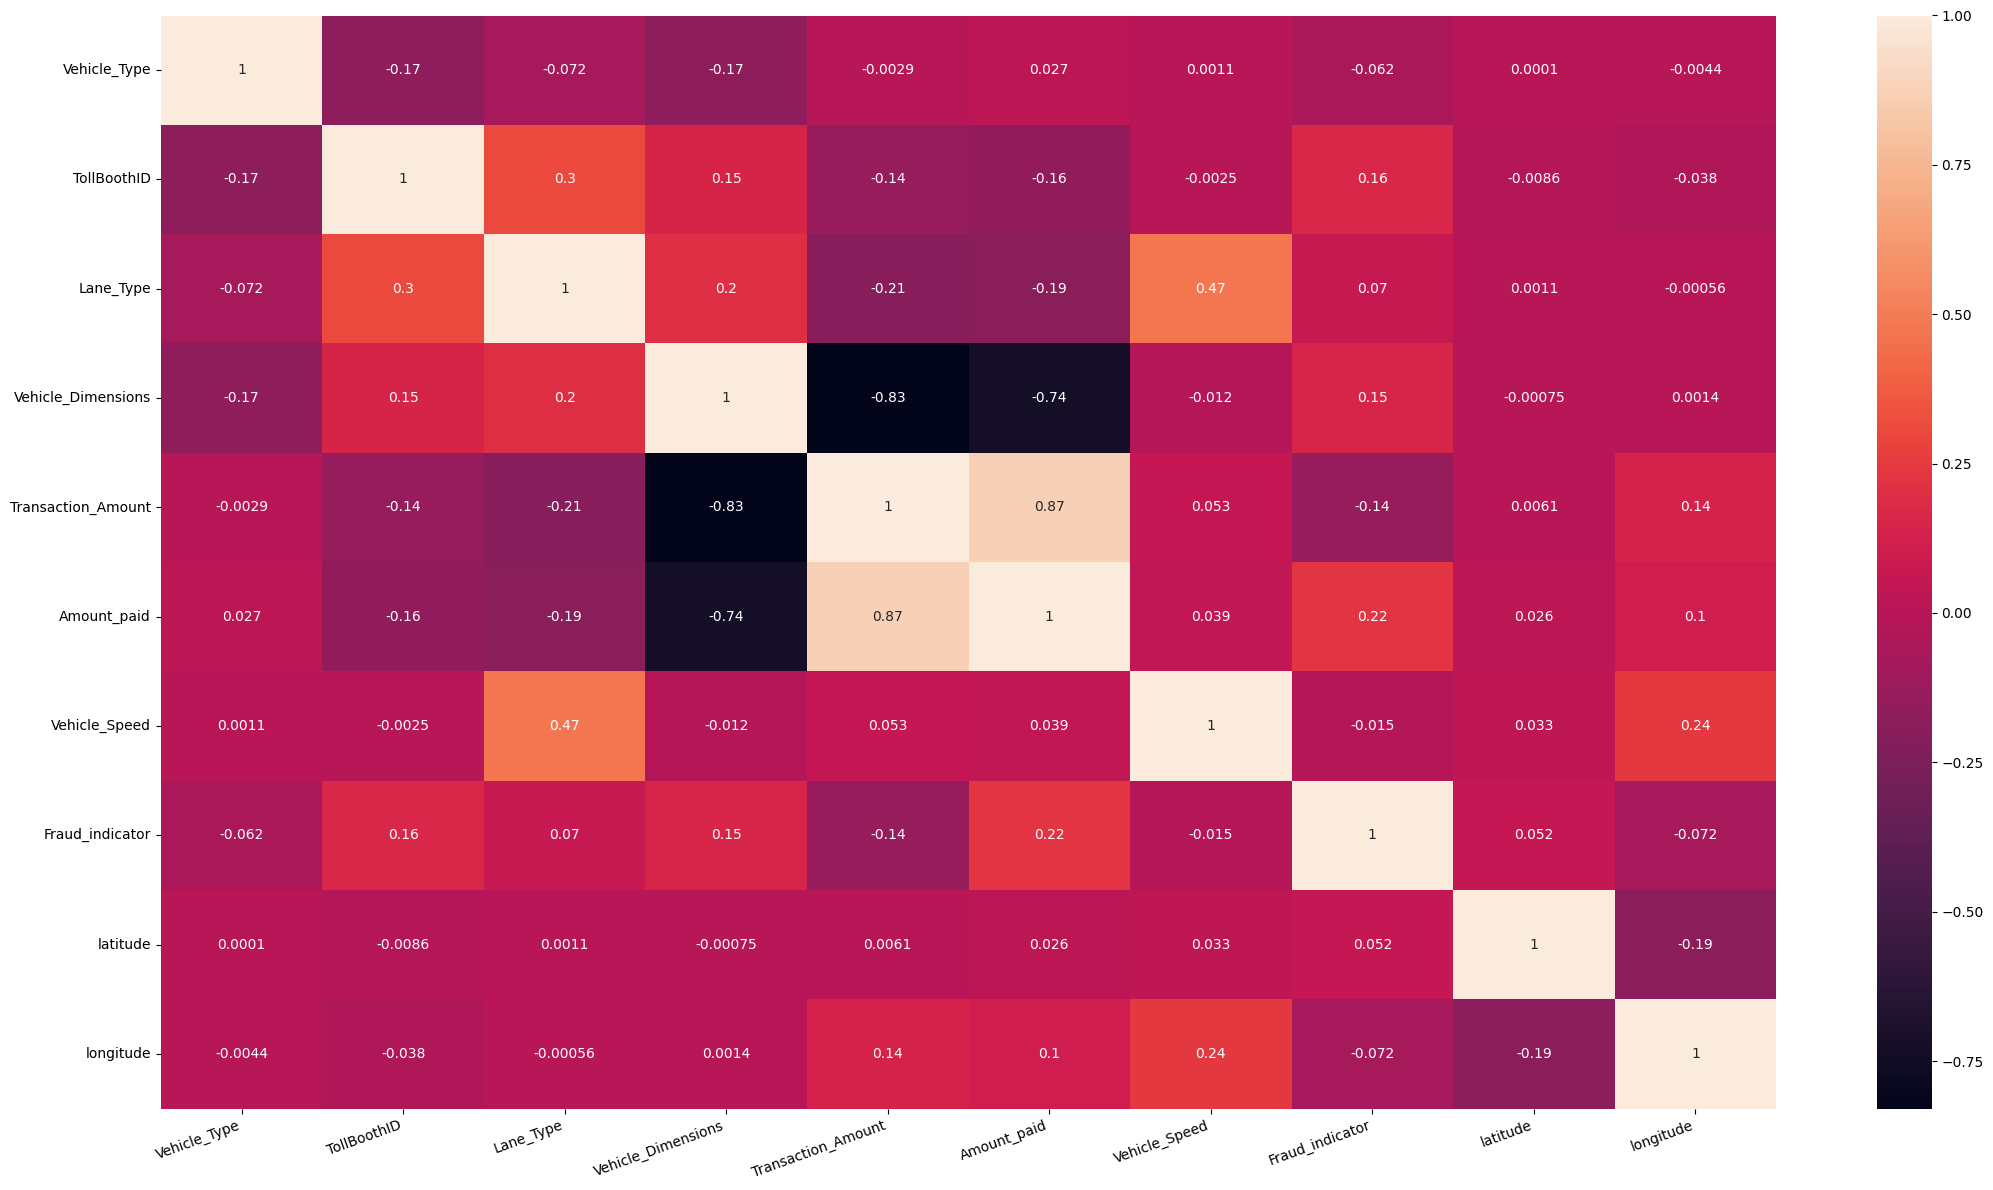

In [93]:
plt.figure(figsize=(22,12))
sns.heatmap(cr, annot=True)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [94]:
#m=MinMaxScaler()

In [95]:
#s=StandardScaler()

In [96]:
#df['Transaction_Amount']=m.fit_transform(df[['Transaction_Amount']])
#df['Transaction_Amount']=s.fit_transform(df[['Transaction_Amount']])

In [97]:
#df['Amount_paid']=m.fit_transform(df[['Amount_paid']])
#df['Amount_paid']=s.fit_transform(df[['Amount_paid']])

In [98]:
#df['Vehicle_Speed']=m.fit_transform(df[['Vehicle_Speed']])
#df['Vehicle_Speed']=s.fit_transform(df[['Vehicle_Speed']])

In [99]:
x=df.drop('Fraud_indicator',axis='columns')
y=df['Fraud_indicator']

In [100]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [101]:
lg=LogisticRegression(max_iter=1000)

In [102]:
lg.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [103]:
lg.score(x_test,y_test)

0.984

In [104]:
y_pred_lg=lg.predict(x_test)

In [105]:
y_test[0:20],y_pred_lg[0:20]

(1501    1
 2586    1
 2653    1
 1055    1
 705     1
 106     1
 589     1
 2468    0
 2413    1
 1600    1
 2464    1
 228     0
 915     1
 794     1
 3021    1
 3543    0
 1073    1
 3351    1
 1744    1
 1084    1
 Name: Fraud_indicator, dtype: int64,
 array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1]))

In [106]:
cr=classification_report(y_test,y_pred_lg)
print(cr)

              precision    recall  f1-score   support

           0       1.00      0.93      0.96       217
           1       0.98      1.00      0.99       783

    accuracy                           0.98      1000
   macro avg       0.99      0.96      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [107]:
cm_lg=confusion_matrix(y_test,y_pred_lg)
cm_lg

array([[201,  16],
       [  0, 783]])

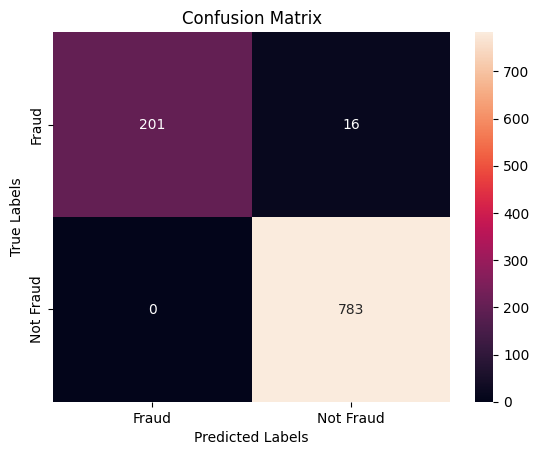

In [108]:
classes = ["Fraud","Not Fraud"]
sns.heatmap(cm_lg, annot=True,fmt="d",xticklabels=classes, yticklabels=classes)   
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [109]:
model_xg=XGBClassifier()
model_xg.fit(x_train,y_train)
y_pred_xg=model_xg.predict(x_test)
report=classification_report(y_test,y_pred_xg)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       217
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [110]:
cm_xg=confusion_matrix(y_test,y_pred_xg)
cm_xg

array([[217,   0],
       [  0, 783]])

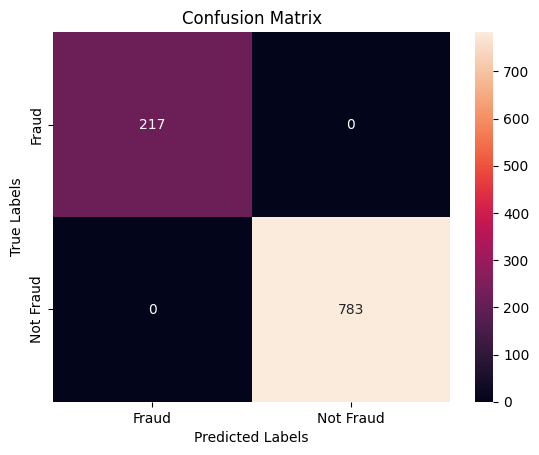

In [111]:
classes = ["Fraud","Not Fraud"]
sns.heatmap(cm_xg, annot=True,fmt="d",xticklabels=classes, yticklabels=classes)   
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [112]:
model_dt=DecisionTreeClassifier()
model_dt.fit(x_train,y_train)
y_pred_dt=model_dt.predict(x_test)
report=classification_report(y_test,y_pred_dt)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       217
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [113]:
cm_dt=confusion_matrix(y_test,y_pred_dt)
cm_dt

array([[216,   1],
       [  0, 783]])

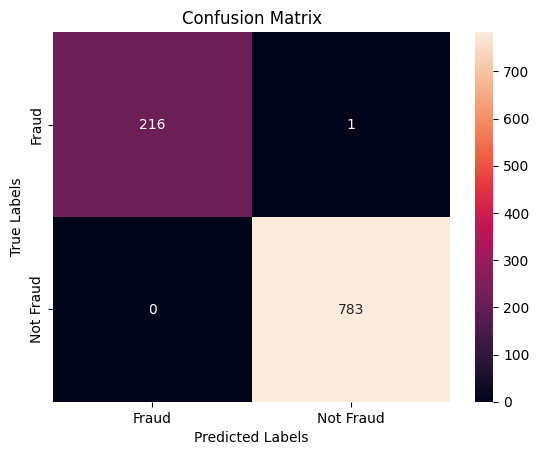

In [114]:
classes = ["Fraud","Not Fraud"]
sns.heatmap(cm_dt, annot=True,fmt="d",xticklabels=classes, yticklabels=classes)   
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [115]:
model_rf=RandomForestClassifier()
model_rf.fit(x_train,y_train)
y_pred_rf=model_rf.predict(x_test)
report=classification_report(y_test,y_pred_rf)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       217
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [116]:
cm_rf=confusion_matrix(y_test,y_pred_rf)
cm_rf

array([[214,   3],
       [  0, 783]])

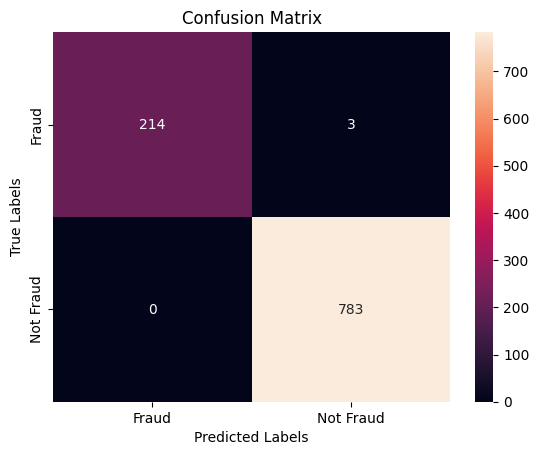

In [117]:
classes = ["Fraud","Not Fraud"]
sns.heatmap(cm_rf, annot=True,fmt="d",xticklabels=classes, yticklabels=classes)   
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()